In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
print('All Packages are Imported Successfully')

All Packages are Imported Successfully


In [5]:
# Pandas display options
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 120)

DATA_PATH = Path('D:/SyntechxHub TAsk/Weak 1/airbnb-eda-project/data/airbnb_listings.csv')  
OUTPUT_DIR = Path('D:/SyntechxHub TAsk/Weak 1/airbnb-eda-project/outputs')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print("Notebook ready. Dataset path:", DATA_PATH)

Notebook ready. Dataset path: D:\SyntechxHub TAsk\Weak 1\airbnb-eda-project\data\airbnb_listings.csv


In [6]:
# Load dataset (adjust parse options if needed)
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Put your CSV inside the D:/SyntechxHub TAsk/Weak 1/airbnb-eda-project/data/ folder."
    )

# Try a common Windows encoding; change if needed (e.g., 'latin1')
df = pd.read_csv(
    DATA_PATH,
    low_memory=False,
    encoding="cp1252",   # or encoding="latin1"
    encoding_errors="ignore"  # optional: skip bad bytes
)

print('Rows, columns:', df.shape)
df.head(3)


Rows, columns: (279712, 33)


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃ‚Â² Paris (Sacre CÃ…â€œur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [10]:
# Basic inspection
print('\n--- dtypes ---')
print(df.dtypes)
print('\n--- head ---')
display(df.head())
print('\n--- tail ---')
display(df.tail())
print('\n--- null counts (top 20) ---')
display(df.isnull().sum().sort_values(ascending=False).head(20))


--- dtypes ---
listing_id                       int64
name                            object
host_id                          int64
host_since                      object
host_location                   object
host_response_time              object
host_response_rate             float64
host_acceptance_rate           float64
host_is_superhost               object
host_total_listings_count      float64
host_has_profile_pic            object
host_identity_verified          object
neighbourhood                   object
district                        object
city                            object
latitude                       float64
longitude                      float64
property_type                   object
room_type                       object
accommodates                     int64
bedrooms                       float64
amenities                       object
price                            int64
minimum_nights                   int64
maximum_nights                   int64
review_sc

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃ‚Â² Paris (Sacre CÃ…â€œur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Vaugirard,NaN,Paris,48.84571,2.30584,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Passy,NaN,Paris,48.85500,2.26979,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f



--- tail ---


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
279707,38338635,Appartement T2 neuf prÃƒÂ¨s du tram T3a Porte ...,31161181,2015-04-13,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Observatoire,NaN,Paris,48.82701,2.31419,Entire apartment,Entire place,2,1.0,"[""Iron"", ""Heating"", ""Washer"", ""Dedicated works...",120,1,7,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279708,38538692,Cozy Studio in Montmartre,10294858,2013-11-27,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.89309,2.33206,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Iron"", ""Heating"", ""Washer"", ""Hair...",60,7,15,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279709,38683356,Nice and cosy mini-appartement in Paris,2238502,2012-04-27,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88699,2.34920,Entire apartment,Entire place,2,1.0,"[""Paid parking off premises"", ""Shampoo"", ""Firs...",50,6,30,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279710,39659000,Charming apartment near Rue Saint Maur / Oberk...,38633695,2015-07-16,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Popincourt,NaN,Paris,48.86687,2.38123,Entire apartment,Entire place,2,1.0,"[""TV"", ""Iron"", ""Kitchen"", ""Hangers"", ""Smoke al...",105,3,18,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279711,40219504,Cosy apartment with view on Canal St Martin,6955618,2013-06-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Enclos-St-Laurent,NaN,Paris,48.87217,2.36320,Entire apartment,Entire place,2,1.0,"[""Shower gel"", ""Shampoo"", ""Iron"", ""Heating"", ""...",70,2,4,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f



--- null counts (top 20) ---


district                       242700
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
review_scores_value             91785
review_scores_location          91775
review_scores_checkin           91771
review_scores_accuracy          91713
review_scores_communication     91687
review_scores_cleanliness       91665
review_scores_rating            91405
bedrooms                        29435
host_location                     840
name                              175
host_identity_verified            165
host_has_profile_pic              165
host_is_superhost                 165
host_since                        165
host_total_listings_count         165
listing_id                          0
dtype: int64

In [7]:
# Cleaning price and numeric columns safely
def clean_price(x):
    if pd.isna(x): 
        return np.nan
    if isinstance(x, (int, float)):
        return x
    s = str(x).replace('$','').replace(',','').strip()
    try:
        return float(s)
    except:
        return np.nan

if 'price' in df.columns:
    df['price'] = df['price'].apply(clean_price)

for col in ['accommodates','bedrooms']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# convert review scores to numeric if present
for col in df.columns:
    if col.startswith('review_scores_'):
        df[col] = pd.to_numeric(df[col], errors='coerce')

display(df[['price','accommodates','bedrooms']].describe().T)

,count,mean,std,min,25%,50%,75%,max
price,279712.0,608.792737,3441.826611,0.0,75.0,150.0,474.0,625216.0
accommodates,279712.0,3.288736,2.133379,0.0,2.0,2.0,4.0,16.0
bedrooms,250277.0,1.515509,1.153080,1.0,1.0,1.0,2.0,50.0


In [8]:
# Summary stats for selected numeric columns
numeric_cols = [c for c in df.columns if df[c].dtype in ['int64','float64']]
# pick commonly interesting ones (fall back to available)
candidates = ['price','accommodates','bedrooms','review_scores_rating','review_scores_cleanliness']
cols = [c for c in candidates if c in df.columns]
print('Using numeric columns:', cols)
display(df[cols].describe().T)

# Also print mean/median/min/max/count for each selected column
for c in cols:
    print(f"\n-- {c} --")
    print('mean:', df[c].mean())
    print('median:', df[c].median())
    print('min:', df[c].min())
    print('max:', df[c].max())
    print('count (non-null):', df[c].count())

Using numeric columns: ['price', 'accommodates', 'bedrooms', 'review_scores_rating', 'review_scores_cleanliness']


,count,mean,std,min,25%,50%,75%,max
price,279712.0,608.792737,3441.826611,0.0,75.0,150.0,474.0,625216.0
accommodates,279712.0,3.288736,2.133379,0.0,2.0,2.0,4.0,16.0
bedrooms,250277.0,1.515509,1.153080,1.0,1.0,1.0,2.0,50.0
review_scores_rating,188307.0,93.405195,10.070437,20.0,91.0,96.0,100.0,100.0
review_scores_cleanliness,188047.0,9.312869,1.146072,2.0,9.0,10.0,10.0,10.0



-- price --
mean: 608.7927368150097
median: 150.0
min: 0
max: 625216
count (non-null): 279712

-- accommodates --
mean: 3.2887362715936392
median: 2.0
min: 0
max: 16
count (non-null): 279712

-- bedrooms --
mean: 1.5155088162316153
median: 1.0
min: 1.0
max: 50.0
count (non-null): 250277

-- review_scores_rating --
mean: 93.40519470864068
median: 96.0
min: 20.0
max: 100.0
count (non-null): 188307

-- review_scores_cleanliness --
mean: 9.312868591362797
median: 10.0
min: 2.0
max: 10.0
count (non-null): 188047


In [9]:
# Example filters (adjust thresholds as needed)
filters = {}

if 'review_scores_rating' in df.columns:
    filters['high_rated'] = df[df['review_scores_rating'] >= 4.8]

# budget private rooms (price <= 80)
filters['budget_private_rooms'] = df[(df.get('room_type') == 'Private room') & (df['price'] <= 80)] if 'room_type' in df.columns and 'price' in df.columns else pd.DataFrame()

# family homes: Houses with 2+ bedrooms
filters['family_homes'] = df[(df.get('property_type') == 'House') & (df['bedrooms'] >= 2)] if 'property_type' in df.columns and 'bedrooms' in df.columns else pd.DataFrame()

# show counts
for k,v in filters.items():
    print(f"{k}: {len(v)} rows")

high_rated: 188307 rows
budget_private_rooms: 35767 rows
family_homes: 0 rows


In [10]:
# Save filtered datasets to outputs/
for name, subset in filters.items():
    if subset is None or subset.empty:
        print(f"Skipping {name} (empty)")
        continue
    out_csv = OUTPUT_DIR / f"{name}.csv"
    subset.to_csv(out_csv, index=False)
    print('Saved', out_csv)

Saved D:\SyntechxHub TAsk\Weak 1\airbnb-eda-project\outputs\high_rated.csv
Saved D:\SyntechxHub TAsk\Weak 1\airbnb-eda-project\outputs\budget_private_rooms.csv
Skipping family_homes (empty)


In [11]:
df.head()       # first 5 rows
df.tail()       # last 5 rows
df.info()       # dtypes and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [16]:
df['price'].describe()  # gives count, mean, min, max, etc.
# or explicitly
df['price'].mean()
df['price'].median()
df['price'].min()
df['price'].max()
df['price'].count()

279712

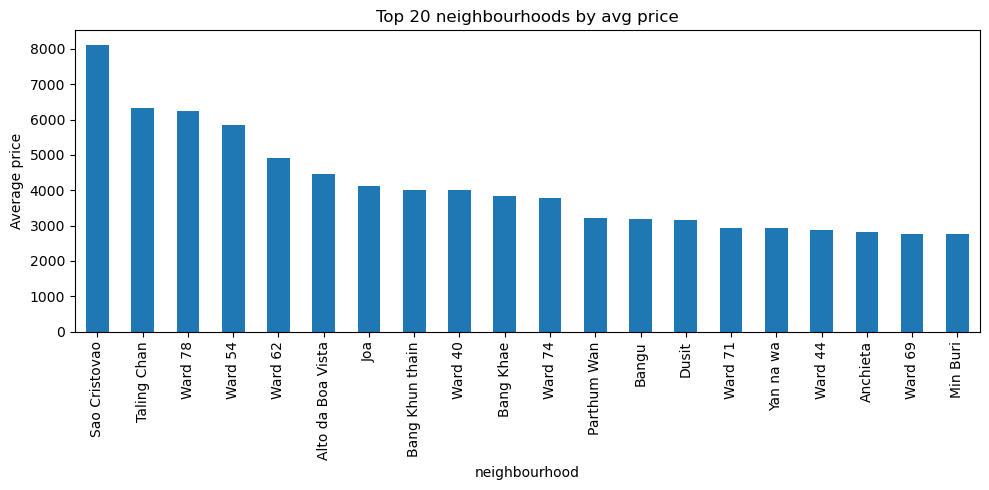

In [16]:
# Avg price by neighbourhood
if 'neighbourhood' in df.columns and 'price' in df.columns:
    grp = df.groupby('neighbourhood')['price'].mean().dropna().sort_values(ascending=False).head(20)
    plt.figure(figsize=(10,5))
    grp.plot.bar()
    plt.title('Top 20 neighbourhoods by avg price')
    plt.ylabel('Average price')
    plt.tight_layout()
    plt.show()

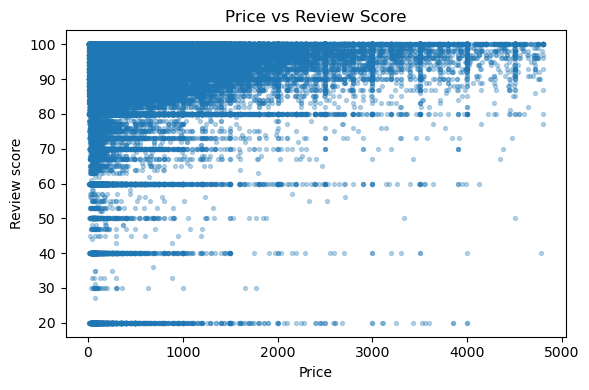

In [17]:
# Price vs review score scatter
if 'price' in df.columns and 'review_scores_rating' in df.columns:
    sample = df[[ 'price','review_scores_rating']].dropna()
    sample = sample[sample['price'] <= sample['price'].quantile(0.99)]
    plt.figure(figsize=(6,4))
    plt.scatter(sample['price'], sample['review_scores_rating'], alpha=0.3, s=8)
    plt.xlabel('Price')
    plt.ylabel('Review score')
    plt.title('Price vs Review Score')
    plt.tight_layout()
    plt.show()